# 02 — Cleaning, data quality, and exploratory analysis

This notebook builds the review-level modeling table and documents collection coverage, label balance, game-level variation, review behavior, time coverage, and data quality. The tables are important: the plots are summaries, not the only evidence.

In [1]:
from pathlib import Path
import html, json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
METADATA_PATH = DATA_DIR / 'steam_games_enriched.csv'
sns.set_theme(style='whitegrid', context='notebook')

## 1. Collection coverage and data quality

In [2]:
metadata = pd.read_csv(METADATA_PATH, dtype={'AppID':'string'})
audit_path = DATA_DIR / 'collection_audit.csv'
if audit_path.exists():
    audit = pd.read_csv(audit_path, dtype={'AppID':'string'})
else:
    raw_ids = {p.name.removesuffix('_reviews.json') for p in RAW_DIR.glob('*_reviews.json')}
    audit = metadata[['AppID','Name']].copy()
    audit['raw_file_exists'] = audit.AppID.astype(str).isin(raw_ids)
    audit['review_count'] = audit.AppID.astype(str).map(lambda x: len(json.loads((RAW_DIR / f'{x}_reviews.json').read_text(encoding='utf-8'))) if (RAW_DIR / f'{x}_reviews.json').exists() else 0)
    audit['collection_status'] = np.where(audit.review_count.gt(0), 'available', 'missing_or_no_reviews')
coverage = audit.assign(has_reviews=audit.review_count.gt(0)).groupby('has_reviews').size().rename('games').reset_index()
available = int(audit.review_count.gt(0).sum()); requested = len(audit); missing = audit.loc[audit.review_count.eq(0), 'AppID'].astype(str).tolist()
print(f'Collection coverage: {available}/{requested} games ({available/requested:.1%})')
print(f'Games without review files or with zero reviews: {len(missing)}')
print('Unresolved AppIDs:', ', '.join(missing) if missing else 'none')
display(audit.sort_values('review_count').head(15))

Collection coverage: 238/241 games (98.8%)
Games without review files or with zero reviews: 3
Unresolved AppIDs: 1568590, 1920960, 700330


,AppID,raw_file_exists,valid_json,review_count,collection_status,error
123,1568590,False,False,0,missing_or_no_reviews,NaN
188,1920960,False,False,0,missing_or_no_reviews,NaN
219,700330,False,False,0,missing_or_no_reviews,NaN
75,3419430,True,True,1,available,NaN
229,3902430,True,True,3,available,NaN
224,736590,True,True,17,available,NaN
59,2066550,True,True,21,available,NaN
37,2709570,True,True,32,available,NaN
7,3678970,True,True,62,available,NaN
212,3202030,True,True,110,available,NaN


In [3]:
records = []
for path in sorted(RAW_DIR.glob('*_reviews.json')):
    appid = path.name.removesuffix('_reviews.json')
    for review in json.loads(path.read_text(encoding='utf-8')):
        author = review.get('author') or {}
        records.append({'AppID':appid, 'author_name':author.get('personaname',''), 'playtime_at_review':author.get('playtime_at_review',0), 'playtime_forever':author.get('playtime_forever',0), 'num_reviews_author':author.get('num_reviews',0), **{k:v for k,v in review.items() if k != 'author'}})
reviews = pd.DataFrame(records).merge(metadata, on='AppID', how='left', suffixes=('','_game'))
print(f'{len(reviews):,} raw reviews loaded from {reviews.AppID.nunique():,} games')
display(reviews[['AppID','Name','review','voted_up','timestamp_created']].head())

215,893 raw reviews loaded from 238 games


,AppID,Name,review,voted_up,timestamp_created
0,1002300,Fear & Hunger,"ohohoho, just started and very ahuen, game goo...",True,1783651777
1,1002300,Fear & Hunger,This game is like dragging your nuts through b...,True,1783639606
2,1002300,Fear & Hunger,"Not scary, just stupid and poorly designed.",False,1783627610
3,1002300,Fear & Hunger,this game is infuriating,True,1783627339
4,1002300,Fear & Hunger,"High Replayability , Great lore and world buil...",True,1783627246


## 2. Cleaning decisions and quality checks

`voted_up` is Steam’s recommendation label. It is our initial supervised target, but it is not a perfect measure of emotional sentiment. Empty text is retained in the cleaned table for auditing and excluded from NLP training.

In [4]:
SLANG = {'gg':'good game','ez':'easy','pog':'exciting','goated':'great','op':'overpowered','nerf':'reduce power','buff':'increase power','imo':'in my opinion','idk':'i do not know'}
ASCII_ART_LINE = re.compile(r'^[^A-Za-z0-9]*$'); HTML_TAG = re.compile(r'<[^>]+>')
def clean_review(value):
    text = html.unescape(str(value or ''))
    text = ' '.join(line for line in text.splitlines() if not ASCII_ART_LINE.fullmatch(line.strip()))
    text = HTML_TAG.sub(' ', text).lower()
    for slang, replacement in SLANG.items(): text = re.sub(rf'\b{re.escape(slang)}\b', replacement, text)
    return re.sub(r'\s+', ' ', text).strip()
reviews['review_clean'] = reviews.review.map(clean_review)
reviews['is_empty_review'] = reviews.review_clean.eq('')
reviews['sentiment'] = reviews.voted_up.map({True:'Positive',False:'Negative'})
reviews['review_word_count'] = reviews.review_clean.str.split().str.len().fillna(0).astype(int)
reviews['review_char_count'] = reviews.review_clean.str.len().fillna(0).astype(int)
reviews['playtime_hours'] = pd.to_numeric(reviews.playtime_at_review, errors='coerce').fillna(0) / 60
reviews['review_date'] = pd.to_datetime(reviews.timestamp_created, unit='s', errors='coerce', utc=True)
reviews['review_year'] = reviews.review_date.dt.year
reviews['review_month'] = reviews.review_date.dt.strftime('%Y-%m')
reviews['helpful_votes'] = pd.to_numeric(reviews.votes_up, errors='coerce').fillna(0)
reviews['engagement_score'] = reviews.helpful_votes + pd.to_numeric(reviews.votes_funny, errors='coerce').fillna(0)
usable = reviews.loc[~reviews.is_empty_review].copy()
print(f'Usable non-empty reviews: {len(usable):,}; empty reviews retained for audit: {int(reviews.is_empty_review.sum()):,}')
display(pd.DataFrame({'rows':[len(reviews)],'games':[reviews.AppID.nunique()],'duplicate_recommendation_ids':[reviews.recommendationid.duplicated().sum()],'empty_text':[reviews.is_empty_review.sum()],'missing_labels':[reviews.voted_up.isna().sum()],'missing_dates':[reviews.review_date.isna().sum()]}))

Usable non-empty reviews: 211,223; empty reviews retained for audit: 4,670


,rows,games,duplicate_recommendation_ids,empty_text,missing_labels,missing_dates
0,215893,238,0,4670,0,0


In [5]:
label_summary = usable.groupby('sentiment').agg(review_count=('sentiment','size'), share=('sentiment',lambda s: len(s)/len(usable)), median_words=('review_word_count','median'), median_playtime_hours=('playtime_hours','median')).reset_index()
print('Label and behavior summary')
display(label_summary)
print('Numeric distribution summary')
display(usable[['review_word_count','review_char_count','playtime_hours','helpful_votes','engagement_score']].describe(percentiles=[.5,.75,.9,.95,.99]).T)

Label and behavior summary


,sentiment,review_count,share,median_words,median_playtime_hours
0,Negative,21555,0.102049,37.0,7.250000
1,Positive,189668,0.897951,11.0,13.616667


Numeric distribution summary


,count,mean,std,min,50%,75%,90%,95%,99%,max
review_word_count,211223.0,41.304044,90.139682,1.0,13.000000,39.000000,100.000000,173.000000,439.000,2000.000000
review_char_count,211223.0,227.758895,509.593497,1.0,67.000000,212.000000,551.000000,955.000000,2465.780,8016.000000
playtime_hours,211223.0,62.210152,284.598754,0.0,12.933333,36.033333,104.296667,213.631667,996.471,32689.483333
helpful_votes,211223.0,1.523541,15.359807,0.0,0.000000,1.000000,2.000000,5.000000,24.000,2471.000000
engagement_score,211223.0,1.809685,19.278153,0.0,0.000000,1.000000,2.000000,5.000000,28.000,4071.000000


## 3. Game-level analysis

Because collection requests up to 1,000 recent reviews per game, total collected reviews are not a meaningful ranking of game popularity. Positive rate, negative count, review length, and engagement are more informative.

In [6]:
game_summary = usable.groupby(['AppID','Name'], dropna=False).agg(review_count=('AppID','size'), positive_count=('voted_up','sum'), positive_rate=('voted_up','mean'), negative_count=('voted_up',lambda s: (~s).sum()), median_words=('review_word_count','median'), median_playtime_hours=('playtime_hours','median'), median_helpful_votes=('helpful_votes','median'), first_review=('review_date','min'), last_review=('review_date','max')).reset_index()
print('Games with the most negative reviews')
display(game_summary.nlargest(20,'negative_count')[['Name','review_count','negative_count','positive_rate']])
print('Lowest positive-rate games, requiring at least 100 reviews')
display(game_summary.loc[game_summary.review_count.ge(100)].nsmallest(20,'positive_rate')[['Name','review_count','negative_count','positive_rate']])
print('Highest positive-rate games, requiring at least 100 reviews')
display(game_summary.loc[game_summary.review_count.ge(100)].nlargest(20,'positive_rate')[['Name','review_count','negative_count','positive_rate']])
game_summary.to_csv(DATA_DIR/'eda_game_summary.csv', index=False, encoding='utf-8-sig')

Games with the most negative reviews


,Name,review_count,negative_count,positive_rate
37,The Texas Chain Saw Massacre,979,504,0.485189
150,Gloria Victis: Medieval MMORPG,992,380,0.616935
38,Wartales,984,369,0.625000
97,Rocket League®,970,350,0.639175
13,Space Engineers 2,992,345,0.652218
26,Overcooked! All You Can Eat,979,316,0.677222
202,City Car Driving,945,290,0.693122
212,Stoneshard,987,280,0.716312
1,The Long Drive,980,253,0.741837
223,The Hong Kong Massacre,934,249,0.733405


Lowest positive-rate games, requiring at least 100 reviews


,Name,review_count,negative_count,positive_rate
37,The Texas Chain Saw Massacre,979,504,0.485189
150,Gloria Victis: Medieval MMORPG,992,380,0.616935
38,Wartales,984,369,0.625000
97,Rocket League®,970,350,0.639175
13,Space Engineers 2,992,345,0.652218
110,Esports Manager 2026,314,103,0.671975
26,Overcooked! All You Can Eat,979,316,0.677222
202,City Car Driving,945,290,0.693122
228,The Scroll of Taiwu : Beyond The Dome,717,210,0.707113
212,Stoneshard,987,280,0.716312


Highest positive-rate games, requiring at least 100 reviews


,Name,review_count,negative_count,positive_rate
133,Creature Kitchen,995,4,0.995980
30,Patrick's Parabox,982,8,0.991853
135,Magical Girl Witch Trials,419,4,0.990453
170,Train45,293,3,0.989761
35,Doki Doki Literature Club Plus!,988,13,0.986842
64,Chants of Sennaar,981,13,0.986748
219,Doki Doki Literature Club!,214,3,0.985981
164,Plants vs. Zombies GOTY Edition,982,14,0.985743
185,Stardew Valley,976,15,0.984631
10,People Playground,983,17,0.982706


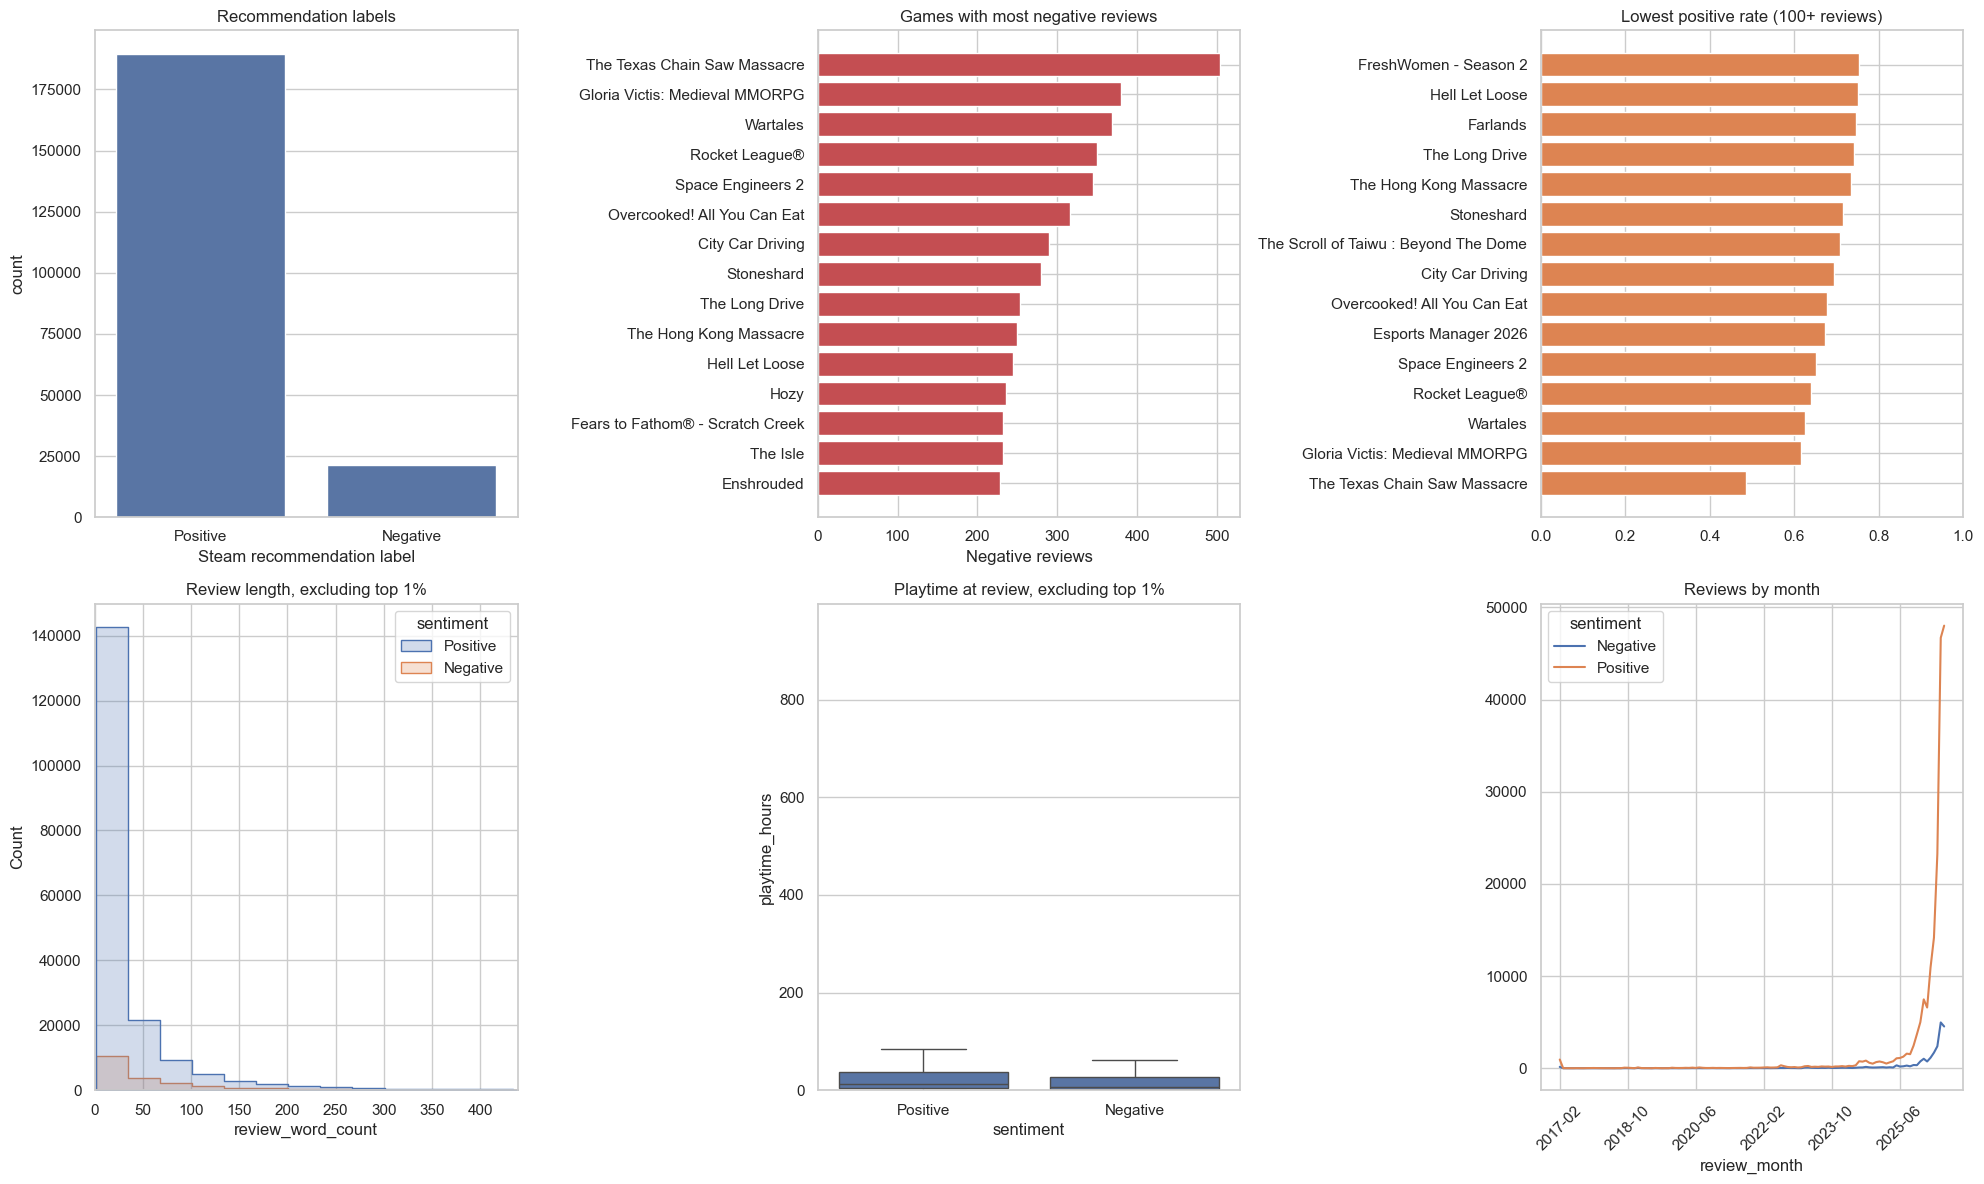

In [7]:
fig, axes = plt.subplots(2,3, figsize=(20,12))
sns.countplot(data=usable, x='sentiment', ax=axes[0,0]); axes[0,0].set_title('Recommendation labels'); axes[0,0].set_xlabel('Steam recommendation label')
top_negative = game_summary.nlargest(15,'negative_count').sort_values('negative_count'); axes[0,1].barh(top_negative.Name, top_negative.negative_count, color='#c44e52'); axes[0,1].set_title('Games with most negative reviews'); axes[0,1].set_xlabel('Negative reviews')
rate_games = game_summary.loc[game_summary.review_count.ge(100)].nsmallest(15,'positive_rate').sort_values('positive_rate'); axes[0,2].barh(rate_games.Name, rate_games.positive_rate, color='#dd8452'); axes[0,2].set_xlim(0,1); axes[0,2].set_title('Lowest positive rate (100+ reviews)')
sns.histplot(data=usable, x='review_word_count', hue='sentiment', bins=60, element='step', ax=axes[1,0]); axes[1,0].set_xlim(0, usable.review_word_count.quantile(.99)); axes[1,0].set_title('Review length, excluding top 1%')
sns.boxplot(data=usable, x='sentiment', y='playtime_hours', showfliers=False, ax=axes[1,1]); axes[1,1].set_ylim(0, usable.playtime_hours.quantile(.99)); axes[1,1].set_title('Playtime at review, excluding top 1%')
monthly = usable.groupby(['review_month','sentiment']).size().unstack(fill_value=0); monthly.plot(ax=axes[1,2], title='Reviews by month'); axes[1,2].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 4. Coverage and collection limitations

The coverage chart is deliberately annotated because 238 available games versus 3 unresolved games makes a normal bar chart visually misleading. The three unresolved IDs are not evidence that the games have no Steam reviews; they mean this collection returned no usable review payload at collection time.

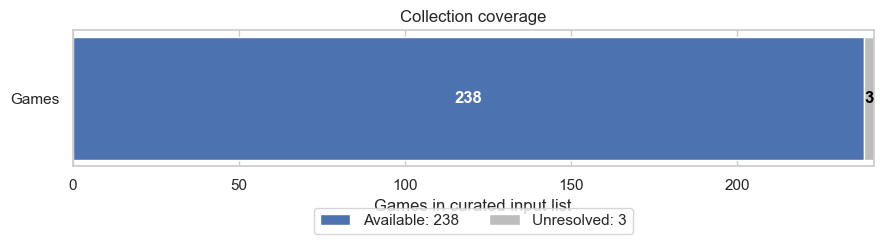

Coverage is 238/241, not 0 missing: unresolved AppIDs = ['1568590', '1920960', '700330']


In [8]:
fig, ax = plt.subplots(figsize=(9,2.8))
ax.barh(['Games'], [available], color='#4c72b0', label=f'Available: {available}')
if missing: ax.barh(['Games'], [len(missing)], left=[available], color='#bdbdbd', label=f'Unresolved: {len(missing)}')
ax.set_xlim(0, requested); ax.set_xlabel('Games in curated input list'); ax.set_title('Collection coverage'); ax.legend(loc='upper center', bbox_to_anchor=(.5,-.25), ncol=2)
ax.text(available/2, 0, str(available), ha='center', va='center', color='white', fontweight='bold')
if missing: ax.text(available + len(missing)/2, 0, str(len(missing)), ha='center', va='center', color='black', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Coverage is {available}/{requested}, not 0 missing: unresolved AppIDs = {missing}')

## 5. Save the modeling table

The saved table keeps the raw review fields plus derived fields. Modeling should filter `is_empty_review == False` and use `voted_up` as the target.

In [9]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
reviews.to_csv(DATA_DIR/'reviews_clean.csv', index=False, encoding='utf-8-sig')
usable.groupby('sentiment').size().rename('review_count').reset_index().to_csv(DATA_DIR/'eda_sentiment_summary.csv', index=False, encoding='utf-8-sig')
print(f'Saved {len(reviews):,} rows; {len(usable):,} are usable for NLP training.')

Saved 215,893 rows; 211,223 are usable for NLP training.
